# Recommendation Model Visualizations

**Notebook version:** updated algorithm comparison panels and markdown explanations on 2026-05-17.

This notebook visualizes both:

- final model evaluation outputs
- training and synthetic-dataset diagnostics

Recommended workflow before running this notebook:

```powershell
python Python/scripts/train.py
python Python/scripts/export_visualization_data.py --out-dir artifacts/model-viz
```

If you do not retrain first, the standard evaluation files will still work, but the new per-iteration gradient boosting traces and learning-curve plots may be empty until the model is retrained with the updated pipeline.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Adjust this if you want to point at another export folder.
BASE_DIR = (Path("..") / "artifacts" / "model-viz").resolve()
BASE_DIR

WindowsPath('C:/Users/jmvel/Codes/jobpath/artifacts/model-viz')

In [2]:
def read_csv(name):
    path = BASE_DIR / name
    if not path.exists():
        return pd.DataFrame()
    return pd.read_csv(path)

feature_importances = read_csv("feature_importances.csv")
feature_stats = read_csv("feature_stats.csv")
evaluation_metrics = read_csv("evaluation_metrics.csv")
calibration_bins = read_csv("calibration_bins.csv")
per_class_metrics = read_csv("per_class_metrics.csv")
confusion = read_csv("test_ensemble_confusion_matrix.csv")
hard_validation_tags = read_csv("hard_validation_tags.csv")
training_profile_debug = read_csv("training_profile_debug.csv")
training_class_dist = read_csv("training_split_class_distribution.csv")
training_level_dist = read_csv("training_split_level_distribution.csv")
training_archetype_dist = read_csv("training_split_archetype_distribution.csv")
training_relationship_dist = read_csv("training_split_relationship_distribution.csv")
training_hard_tags = read_csv("training_split_hard_tag_distribution.csv")
gb_trace = read_csv("gradient_boosting_iteration_trace.csv")
learning_curve = read_csv("synthetic_learning_curve.csv")
hyperparameter_search_candidates = read_csv("hyperparameter_search_candidates.csv")
hyperparameter_search_summary = read_csv("hyperparameter_search_summary.csv")
ensemble_weight_search_trace = read_csv("ensemble_weight_search_trace.csv")
ensemble_weight_search_summary = read_csv("ensemble_weight_search_summary.csv")
model_comparison_tuning = read_csv("model_comparison_before_after_tuning.csv")

for name, frame in {
    "feature_importances": feature_importances,
    "evaluation_metrics": evaluation_metrics,
    "training_profile_debug": training_profile_debug,
    "gb_trace": gb_trace,
    "learning_curve": learning_curve,
    "hyperparameter_search_candidates": hyperparameter_search_candidates,
    "hyperparameter_search_summary": hyperparameter_search_summary,
    "ensemble_weight_search_trace": ensemble_weight_search_trace,
    "model_comparison_tuning": model_comparison_tuning,
}.items():
    print(f"{name}: {frame.shape}")


feature_importances: (94, 7)
evaluation_metrics: (12, 8)
training_profile_debug: (31, 15)
gb_trace: (80, 17)
learning_curve: (5, 15)


## Post-Training Evaluation Visuals

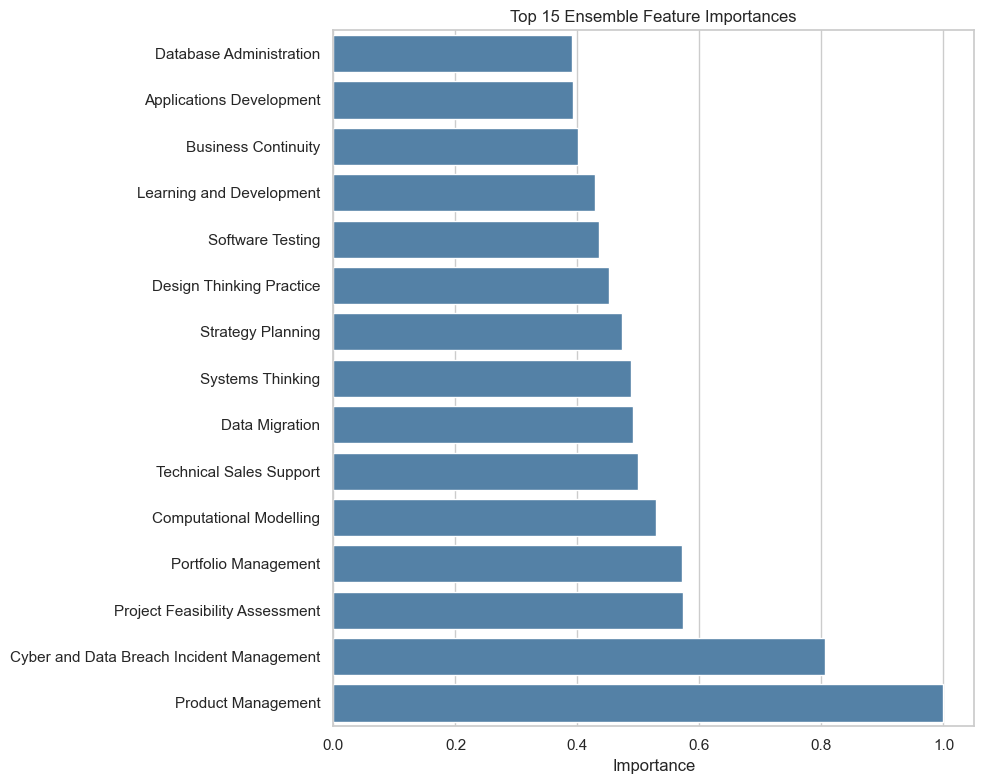

In [3]:
if feature_importances.empty:
    print("feature_importances.csv is empty or missing")
else:
    top_features = feature_importances.head(15).sort_values("ensemble")
    plt.figure(figsize=(10, 8))
    sns.barplot(data=top_features, x="ensemble", y="featureLabel", color="steelblue")
    plt.title("Top 15 Ensemble Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This chart ranks the competency features that most influenced the final ensemble recommendation model. Higher bars mean the model relied more heavily on that competency when separating careers. These values help with interpretability, but they should not be read as direct causality; they show model dependence, not real-world cause-and-effect. For the thesis, this is useful because it shows that recommendations are being driven by understandable competency signals rather than opaque or random behavior.


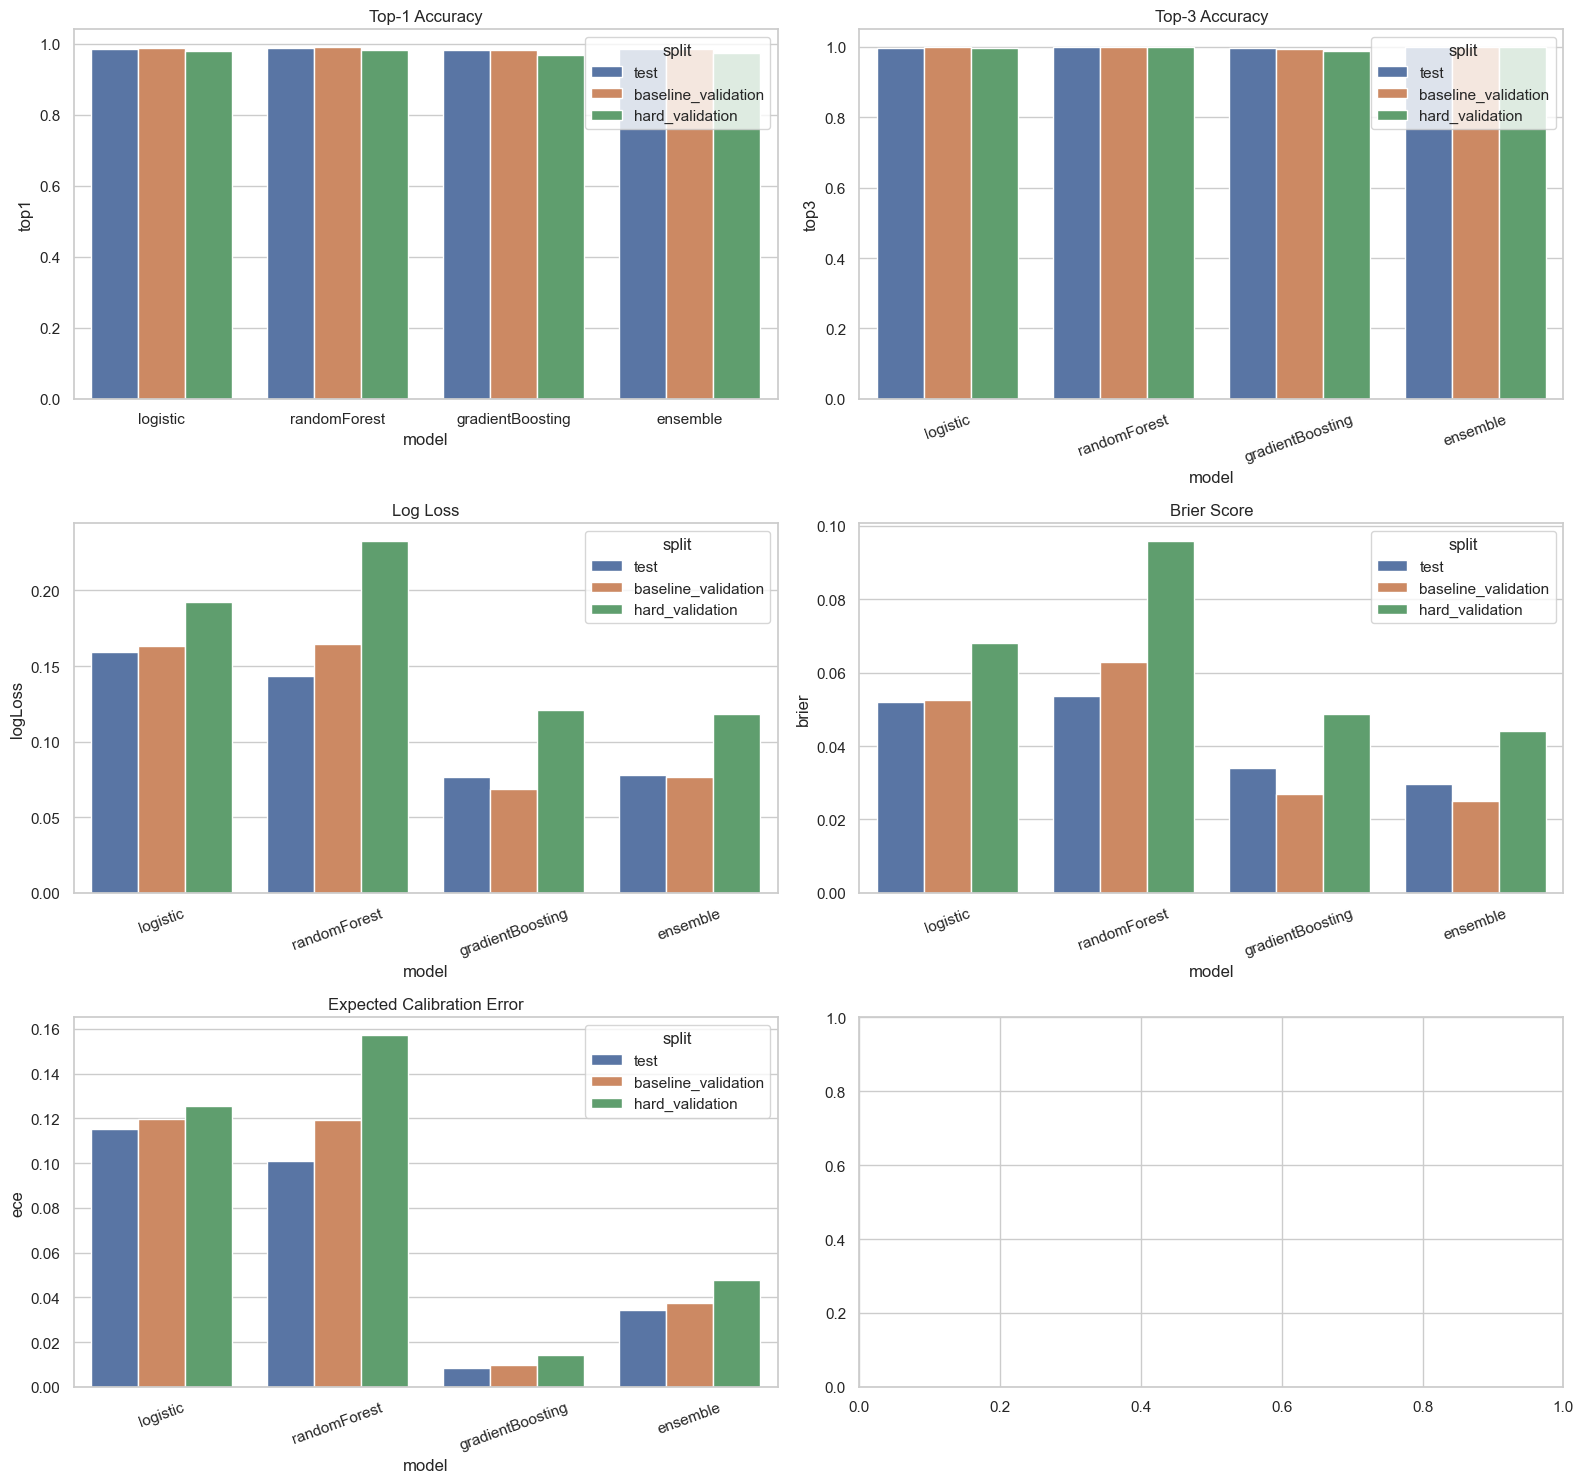

In [4]:
if evaluation_metrics.empty:
    print("evaluation_metrics.csv is empty or missing")
else:
    fig, axes = plt.subplots(3, 2, figsize=(16, 15))
    sns.barplot(data=evaluation_metrics, x="model", y="top1", hue="split", ax=axes[0, 0])
    axes[0, 0].set_title("Top-1 Accuracy")
    sns.barplot(data=evaluation_metrics, x="model", y="top3", hue="split", ax=axes[0, 1])
    axes[0, 1].set_title("Top-3 Accuracy")
    axes[0, 1].tick_params(axis="x", rotation=20)
    sns.barplot(data=evaluation_metrics, x="model", y="logLoss", hue="split", ax=axes[1, 0])
    axes[1, 0].set_title("Log Loss")
    axes[1, 0].tick_params(axis="x", rotation=20)
    sns.barplot(data=evaluation_metrics, x="model", y="brier", hue="split", ax=axes[1, 1])
    axes[1, 1].set_title("Brier Score")
    axes[1, 1].tick_params(axis="x", rotation=20)
    sns.barplot(data=evaluation_metrics, x="model", y="ece", hue="split", ax=axes[2, 0])
    axes[2, 0].set_title("Expected Calibration Error")
    axes[2, 0].tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

These metric panels compare the baseline models and the ensemble across data splits. Higher `top1` and `top3` values are better, while lower `logLoss`, `brier`, and `ece` values are better. When the ensemble is strong on the test split and the train-validation-test gaps stay controlled, that supports the claim that the model generalizes instead of only memorizing the synthetic training set. This figure is especially helpful when defending why the ensemble setup was chosen over any single model.


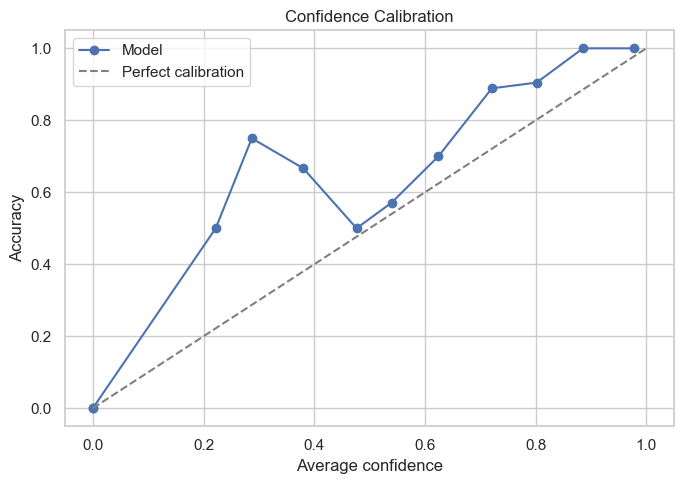

In [5]:
if calibration_bins.empty:
    print("calibration_bins.csv is empty or missing")
else:
    plt.figure(figsize=(7, 5))
    plt.plot(calibration_bins["avgConfidence"], calibration_bins["accuracy"], marker="o", label="Model")
    plt.plot([0, 1], [0, 1], "--", color="gray", label="Perfect calibration")
    plt.xlabel("Average confidence")
    plt.ylabel("Accuracy")
    plt.title("Confidence Calibration")
    plt.legend()
    plt.tight_layout()
    plt.show()

The calibration plot checks whether predicted confidence matches actual correctness. Points close to the diagonal indicate that, for example, predictions made with about 80% confidence are correct about 80% of the time. Points below the line suggest overconfidence, while points above it suggest underconfidence. For the thesis, this matters because an effective recommender should not only be accurate; it should also express uncertainty in a trustworthy way.


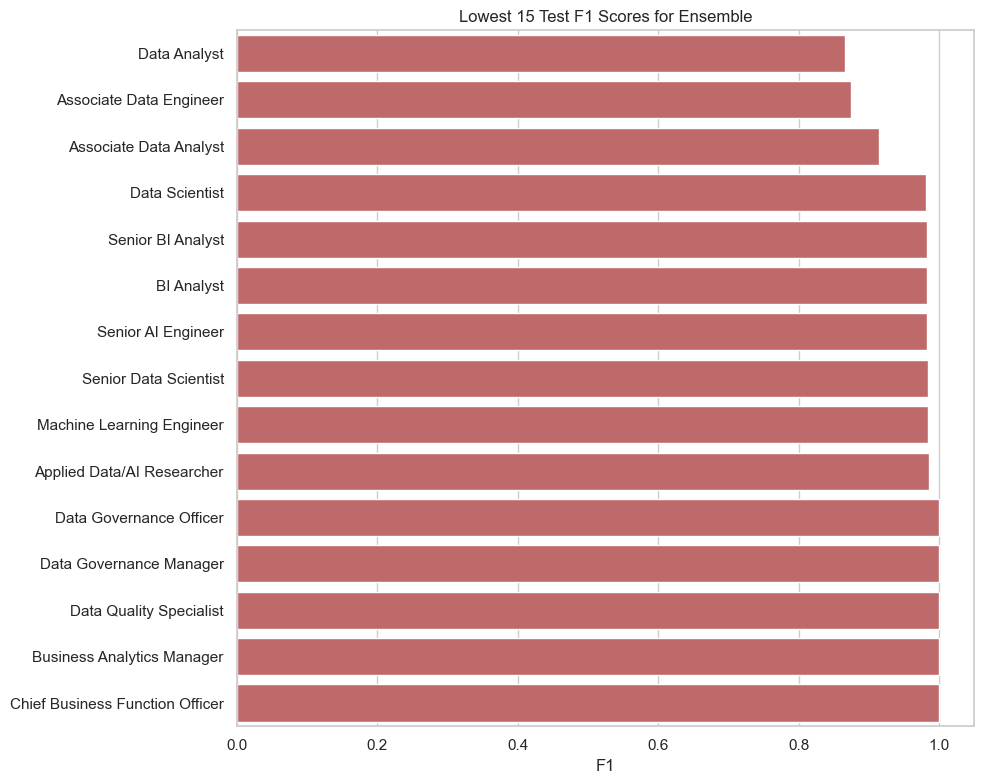

In [6]:
if per_class_metrics.empty:
    print("per_class_metrics.csv is empty or missing")
else:
    ensemble_test = per_class_metrics.query("split == 'test' and model == 'ensemble'").copy()
    lowest_f1 = ensemble_test.sort_values("f1").head(15)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=lowest_f1, x="f1", y="className", color="indianred")
    plt.title("Lowest 15 Test F1 Scores for Ensemble")
    plt.xlabel("F1")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This view highlights the career classes where the ensemble struggles most, based on test-set F1 score. Low F1 usually means the class is either harder to distinguish, underrepresented, or closely overlaps with nearby careers. Rather than weakening the thesis, this helps present the work honestly by showing where the model is strong and where future improvements are needed. It also helps justify later refinements such as additional questions, better competency definitions, or more synthetic support for difficult classes.


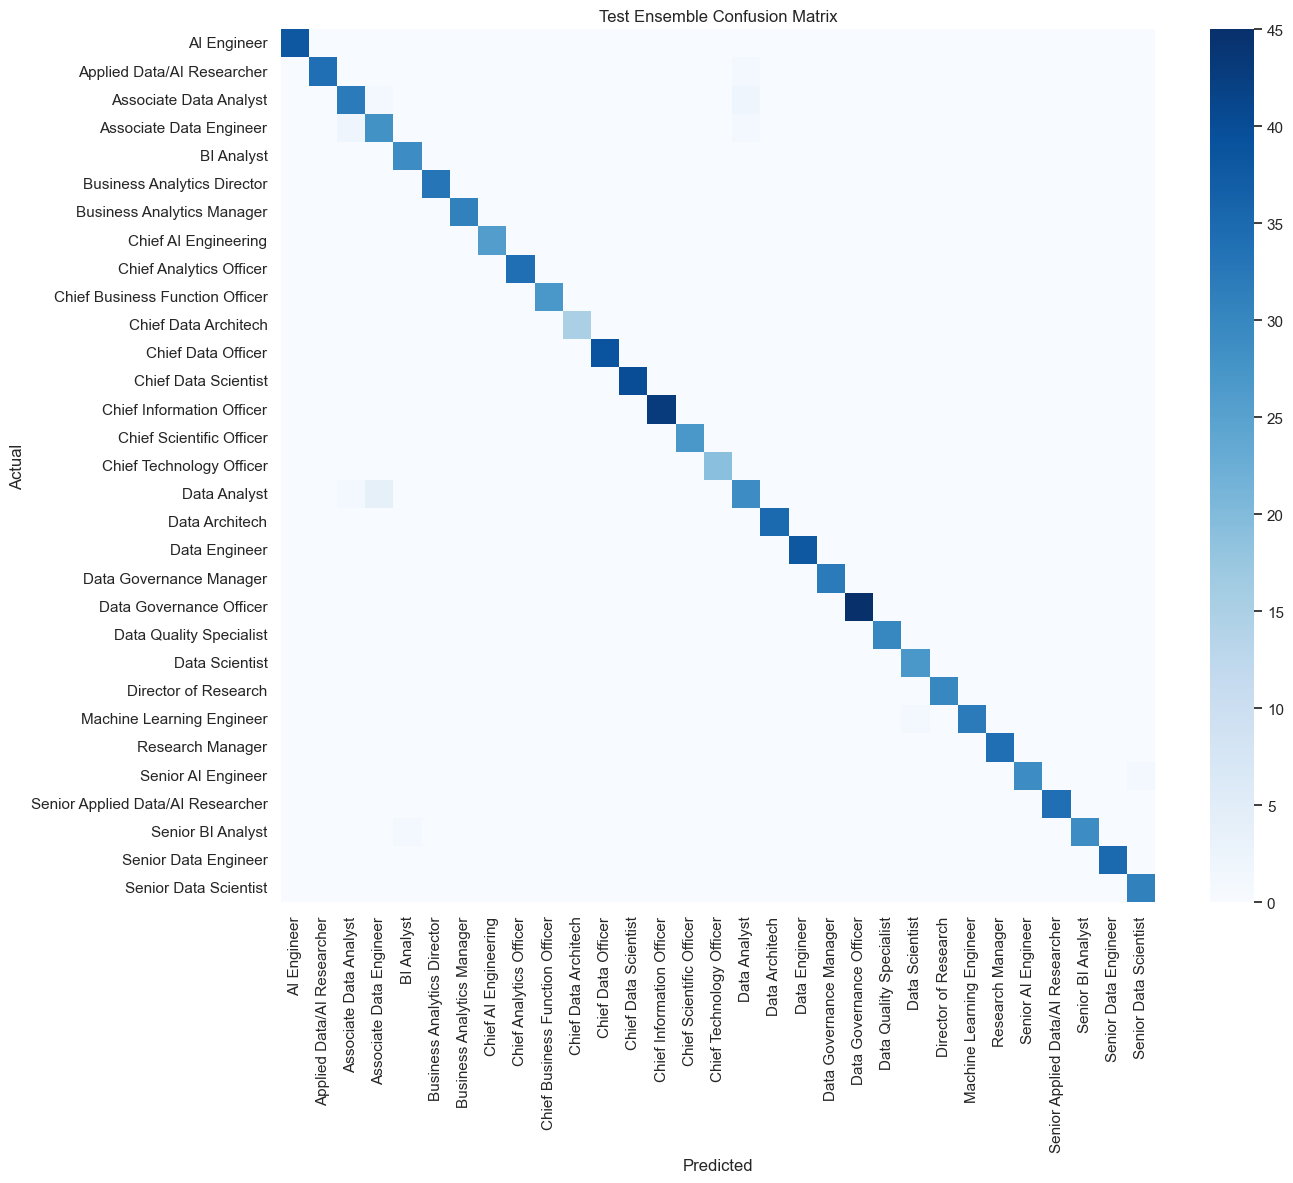

In [7]:
if confusion.empty:
    print("test_ensemble_confusion_matrix.csv is empty or missing")
else:
    cm = confusion.pivot(index="actualClass", columns="predictedClass", values="count").fillna(0)
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues")
    plt.title("Test Ensemble Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In the confusion matrix, correct predictions appear on the main diagonal and mistakes appear off-diagonal. The most important pattern to inspect is whether errors are scattered randomly or concentrated among related careers. If confusion tends to happen between similar paths, that suggests the model is learning meaningful structure instead of failing arbitrarily. This plot is a strong defense tool because it lets you explain not just how often the model is wrong, but the kind of wrong it tends to make.


## Synthetic Dataset Defense Visuals

These plots are meant to help explain why the synthetic dataset is useful for training:

- coverage across classes and levels
- variation around each profile base vector
- multiple archetypes per role
- harder validation subsets that stress-test the model
- learning-curve behavior as more synthetic samples are added


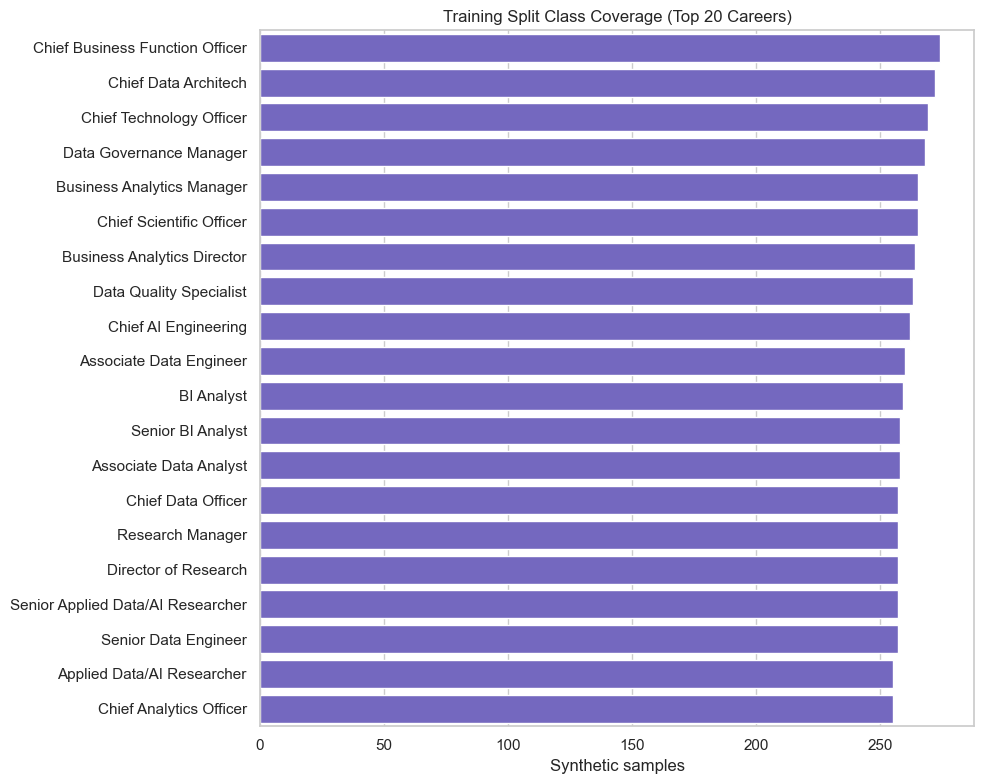

In [8]:
if training_class_dist.empty:
    print("training_split_class_distribution.csv is empty or missing")
else:
    train_only = training_class_dist.query("split == 'train'").sort_values("count", ascending=False).head(20)
    plt.figure(figsize=(10, 8))
    sns.barplot(data=train_only, x="count", y="careerName", color="slateblue")
    plt.title("Training Split Class Coverage (Top 20 Careers)")
    plt.xlabel("Synthetic samples")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

This chart shows how many synthetic training profiles were assigned to each career, focusing on the top-covered classes. It helps demonstrate whether the dataset provides broad class exposure or leaves some careers sparsely represented. Strong coverage supports the argument that synthetic generation was used to reduce imbalance and give the model enough examples to learn each recommendation target. If some careers remain low, that becomes a concrete area for future data expansion.


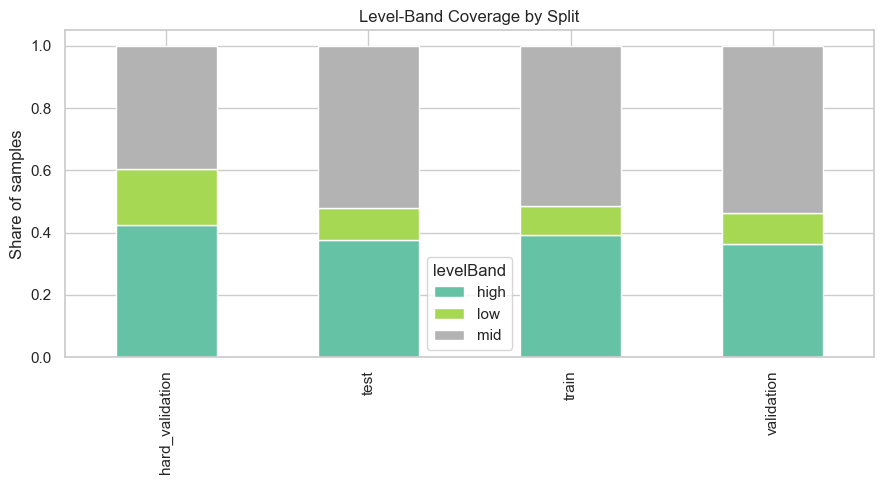

In [9]:
if training_level_dist.empty:
    print("training_split_level_distribution.csv is empty or missing")
else:
    level_pivot = training_level_dist.pivot(index="split", columns="levelBand", values="count").fillna(0)
    level_share = level_pivot.div(level_pivot.sum(axis=1), axis=0)
    level_share.plot(kind="bar", stacked=True, figsize=(9, 5), colormap="Set2")
    plt.title("Level-Band Coverage by Split")
    plt.ylabel("Share of samples")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

This figure compares low-, mid-, and high-level profile coverage across the train, validation, and test splits. A healthier synthetic dataset will show representation across experience bands rather than concentrating heavily in just one level. When these distributions are reasonably balanced across splits, it strengthens the claim that evaluation results are not biased toward a single maturity band. In thesis terms, this helps defend that the recommender is learning across stages of career development.


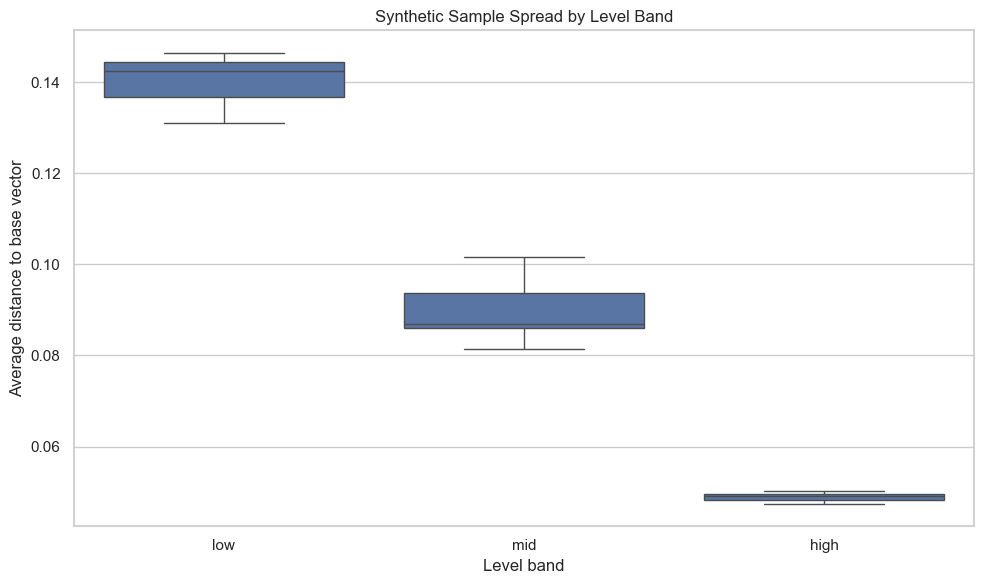

In [10]:
if training_profile_debug.empty:
    print("training_profile_debug.csv is empty or missing")
else:
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=training_profile_debug, x="levelBand", y="avgDistanceToBase", order=["low", "mid", "high"])
    plt.title("Synthetic Sample Spread by Level Band")
    plt.xlabel("Level band")
    plt.ylabel("Average distance to base vector")
    plt.tight_layout()
    plt.show()

The spread plot shows how far synthetic profiles drift from their base profile template within each level band. A useful synthetic dataset should introduce enough variation to avoid near-duplicates, while still staying close enough to remain plausible. If the spread is nontrivial but not extreme, that supports the idea that the generator is creating realistic diversity rather than noise. This is one of the most direct visuals for defending synthetic data quality.


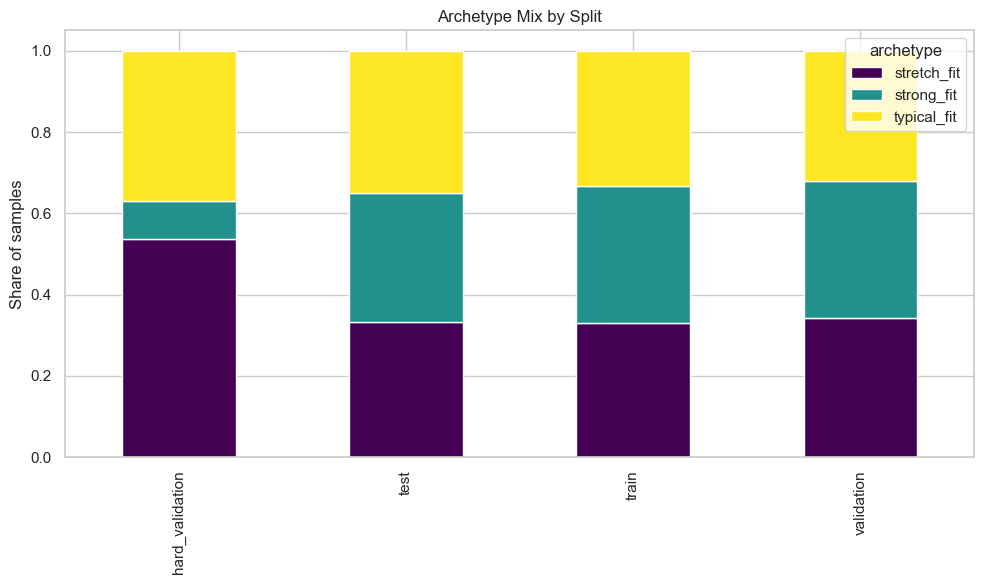

In [17]:
if training_archetype_dist.empty:
    print("training_split_archetype_distribution.csv is empty or missing")
else:
    archetype_pivot = training_archetype_dist.pivot(index="split", columns="archetype", values="count").fillna(0)
    archetype_share = archetype_pivot.div(archetype_pivot.sum(axis=1), axis=0)
    archetype_share.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
    plt.title("Archetype Mix by Split")
    plt.ylabel("Share of samples")
    plt.xlabel("")
    plt.tight_layout()
    plt.show()

This plot summarizes the archetype composition of each split. Consistent archetype presence across training, validation, and test reduces the risk that performance is being inflated by a narrow or biased sample of synthetic personas. If one archetype dominates too strongly, it can signal an imbalance in how examples were generated. For your defense, this chart helps argue that the synthetic dataset reflects varied profile styles rather than a single repeated pattern.


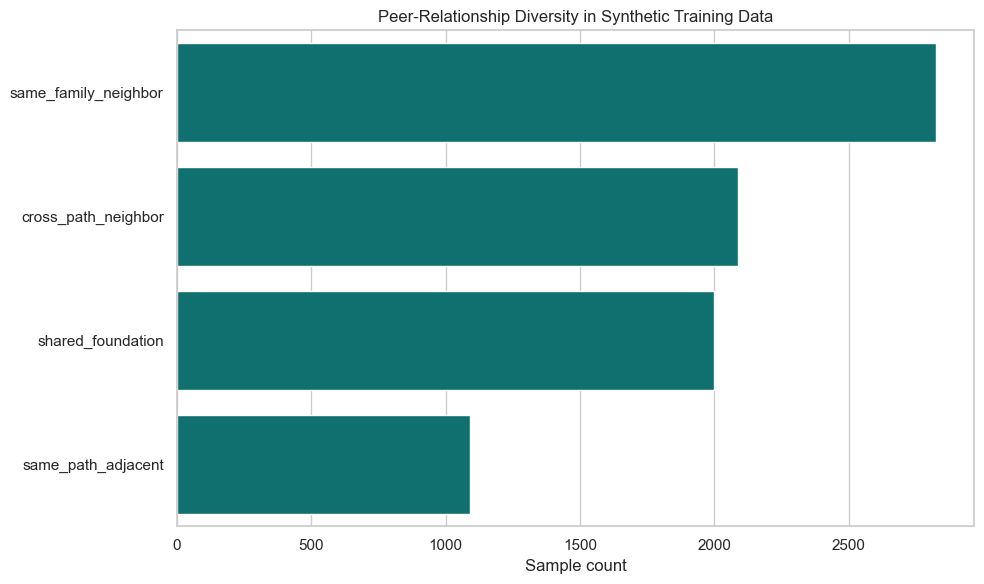

In [12]:
if training_relationship_dist.empty:
    print("training_split_relationship_distribution.csv is empty or missing")
else:
    rel = training_relationship_dist.query("split == 'train'").sort_values("count", ascending=False)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=rel, x="count", y="peerRelationship", color="teal")
    plt.title("Peer-Relationship Diversity in Synthetic Training Data")
    plt.xlabel("Sample count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

Peer-relationship diversity captures how broadly the synthetic profiles represent neighboring, stepping-stone, or related career relationships. A diverse distribution here suggests that the generated data does more than replicate isolated job labels; it preserves structure about how careers relate to one another. That is valuable for a recommendation system because many real users sit between adjacent paths. In the thesis, this helps justify synthetic data as a structured augmentation strategy rather than simple oversampling.


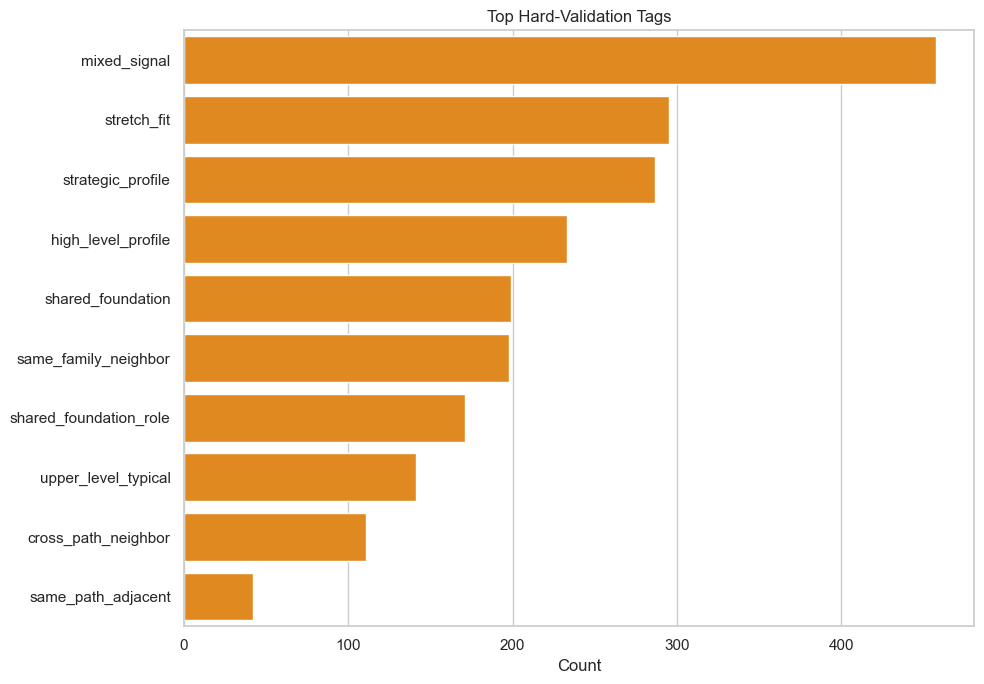

In [13]:
if training_hard_tags.empty:
    print("training_split_hard_tag_distribution.csv is empty or missing")
else:
    hard_only = training_hard_tags.query("split == 'hard_validation'").sort_values("count", ascending=False).head(15)
    plt.figure(figsize=(10, 7))
    sns.barplot(data=hard_only, x="count", y="tag", color="darkorange")
    plt.title("Top Hard-Validation Tags")
    plt.xlabel("Count")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

The hard-validation tags identify which kinds of edge cases or stress-test conditions appear most often in the harder validation slice. This helps separate average-case performance from more demanding scenarios. If the model remains reasonable even when these tags are present, that gives a stronger robustness claim than reporting overall accuracy alone. For the thesis, this visualization is useful because it shows you evaluated the recommender under difficult conditions, not only on easy synthetic cases.


## Hyperparameter Tuning Visuals


In [ ]:
if hyperparameter_search_summary.empty:
    print("hyperparameter_search_summary.csv is empty or missing")
else:
    summary = hyperparameter_search_summary.query("model != 'ensemble'").copy()
    comparison_rows = []
    for _, row in summary.iterrows():
        for metric_key, metric_label in [
            ("log_loss", "Log Loss"),
            ("top1", "Top-1 Accuracy"),
            ("ece", "Expected Calibration Error"),
        ]:
            comparison_rows.append(
                {
                    "model": row["model"],
                    "stage": "Baseline",
                    "metric": metric_label,
                    "value": row.get(f"baseline_{metric_key}"),
                }
            )
            comparison_rows.append(
                {
                    "model": row["model"],
                    "stage": "Tuned",
                    "metric": metric_label,
                    "value": row.get(f"tuned_{metric_key}"),
                }
            )
    comparison = pd.DataFrame(comparison_rows).dropna(subset=["value"])
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric_label in zip(axes, ["Log Loss", "Top-1 Accuracy", "Expected Calibration Error"]):
        panel = comparison.query("metric == @metric_label")
        sns.barplot(data=panel, x="model", y="value", hue="stage", ax=ax)
        ax.set_title(f"Baseline vs Tuned: {metric_label}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.legend_.set_title("Configuration")
    plt.tight_layout()
    plt.show()


These panels show whether hyperparameter tuning materially improved each base model before the ensemble stage was even considered. Lower `Log Loss` and `Expected Calibration Error` are better, while higher `Top-1 Accuracy` is better. For thesis defense, this figure supports the claim that tuning was not cosmetic; it changed the quality of the individual learners before they were combined.


In [ ]:
if hyperparameter_search_candidates.empty:
    print("hyperparameter_search_candidates.csv is empty or missing")
else:
    candidates = hyperparameter_search_candidates.dropna(subset=["mean_cv_log_loss", "mean_cv_top1"]).copy()
    candidates["param_label"] = candidates["params"].astype(str).str.replace('{', '', regex=False).str.replace('}', '', regex=False)
    candidates["param_label"] = candidates["param_label"].str.slice(0, 85)
    model_order = ["logistic", "randomForest", "gradientBoosting"]
    fig, axes = plt.subplots(len(model_order), 2, figsize=(18, 16))
    for row_index, model_name in enumerate(model_order):
        ranked = candidates.query("model == @model_name").sort_values("mean_cv_log_loss").head(10).copy()
        scatter = candidates.query("model == @model_name").copy()
        sns.barplot(data=ranked.sort_values("mean_cv_log_loss", ascending=False), x="mean_cv_log_loss", y="param_label", hue="selected", dodge=False, ax=axes[row_index, 0])
        axes[row_index, 0].set_title(f"{model_name}: Top 10 Search Candidates by CV Log Loss")
        axes[row_index, 0].set_xlabel("Mean CV log loss")
        axes[row_index, 0].set_ylabel("Params")
        axes[row_index, 0].legend(title="Selected")

        sns.scatterplot(data=scatter, x="mean_cv_log_loss", y="mean_cv_top1", hue="selected", style="is_default", s=90, ax=axes[row_index, 1])
        axes[row_index, 1].set_title(f"{model_name}: Candidate Frontier")
        axes[row_index, 1].set_xlabel("Mean CV log loss")
        axes[row_index, 1].set_ylabel("Mean CV top-1")
        axes[row_index, 1].legend(title="Selected / Default")
    plt.tight_layout()
    plt.show()


The left column ranks the strongest hyperparameter candidates for each model, while the right column shows the broader search landscape. A strong tuned configuration should appear toward the lower-right region of the scatter plot, where log loss is lower and top-1 accuracy is higher. This is useful when explaining not only which configuration won, but whether it won decisively or only marginally.


In [ ]:
if ensemble_weight_search_trace.empty or ensemble_weight_search_summary.empty:
    print("ensemble_weight_search_trace.csv or ensemble_weight_search_summary.csv is empty or missing")
else:
    trace = ensemble_weight_search_trace.copy()
    summary = ensemble_weight_search_summary.iloc[0]
    selected = trace.query("selected == True").head(1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    sns.scatterplot(data=trace, x="log_loss", y="top1", hue="stage", style="selected", s=100, ax=axes[0])
    axes[0].set_title("Ensemble Weight Search: Candidate Performance")
    axes[0].set_xlabel("Log loss")
    axes[0].set_ylabel("Top-1 accuracy")

    best_weights = pd.DataFrame(
        {
            "model": ["logistic", "randomForest", "gradientBoosting"],
            "weight": [
                selected["logistic_weight"].iloc[0] if not selected.empty else 0.0,
                selected["random_forest_weight"].iloc[0] if not selected.empty else 0.0,
                selected["gradient_boosting_weight"].iloc[0] if not selected.empty else 0.0,
            ],
        }
    )
    sns.barplot(data=best_weights, x="model", y="weight", palette="crest", ax=axes[1])
    axes[1].set_title("Final Tuned Ensemble Weights")
    axes[1].set_ylim(0.0, 1.0)
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Weight")
    plt.tight_layout()
    plt.show()


The ensemble search plot shows how the coarse and fine stages explored different weight combinations before selecting the final blend. If the chosen point sits near the best region rather than as an isolated accident, that supports the use of a tuned weighted-average ensemble instead of a manually chosen mixture. The weight bar chart then makes the final model composition easy to communicate.


In [ ]:
if model_comparison_tuning.empty or evaluation_metrics.empty:
    print("model_comparison_before_after_tuning.csv or evaluation_metrics.csv is empty or missing")
else:
    holdout = evaluation_metrics.copy()
    holdout = holdout[holdout["model"].isin(["logistic", "randomForest", "gradientBoosting", "ensemble"])].copy()
    holdout = holdout.rename(columns={"split": "stage", "logLoss": "log_loss"})

    oof_rows = []
    for _, row in model_comparison_tuning.iterrows():
        oof_rows.append({"model": row["model"], "stage": "train_oof", "top1": row.get("tuned_top1"), "log_loss": row.get("tuned_log_loss"), "ece": row.get("tuned_ece")})
    oof_frame = pd.DataFrame(oof_rows)
    combined = pd.concat([
        holdout[["model", "stage", "top1", "log_loss", "ece"]],
        oof_frame,
    ], ignore_index=True)
    combined["stage"] = pd.Categorical(combined["stage"], categories=["train_oof", "baseline_validation", "hard_validation", "test"], ordered=True)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, metric_key, title in [
        (axes[0], "top1", "Top-1 Accuracy"),
        (axes[1], "log_loss", "Log Loss"),
        (axes[2], "ece", "Expected Calibration Error"),
    ]:
        sns.barplot(data=combined, x="stage", y=metric_key, hue="model", ax=ax)
        ax.set_title(f"Tuned Model Comparison: {title}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.legend_.set_title("Model")
    plt.tight_layout()
    plt.show()


This final comparison brings the tuned base models and tuned ensemble together across train-OOF, baseline validation, hard validation, and test. It is especially useful for explaining whether the ensemble remains the strongest option after tuning all individual learners, and whether the tuned gains persist under the harder validation split and the final held-out test set.


## Retraining Trace Visuals

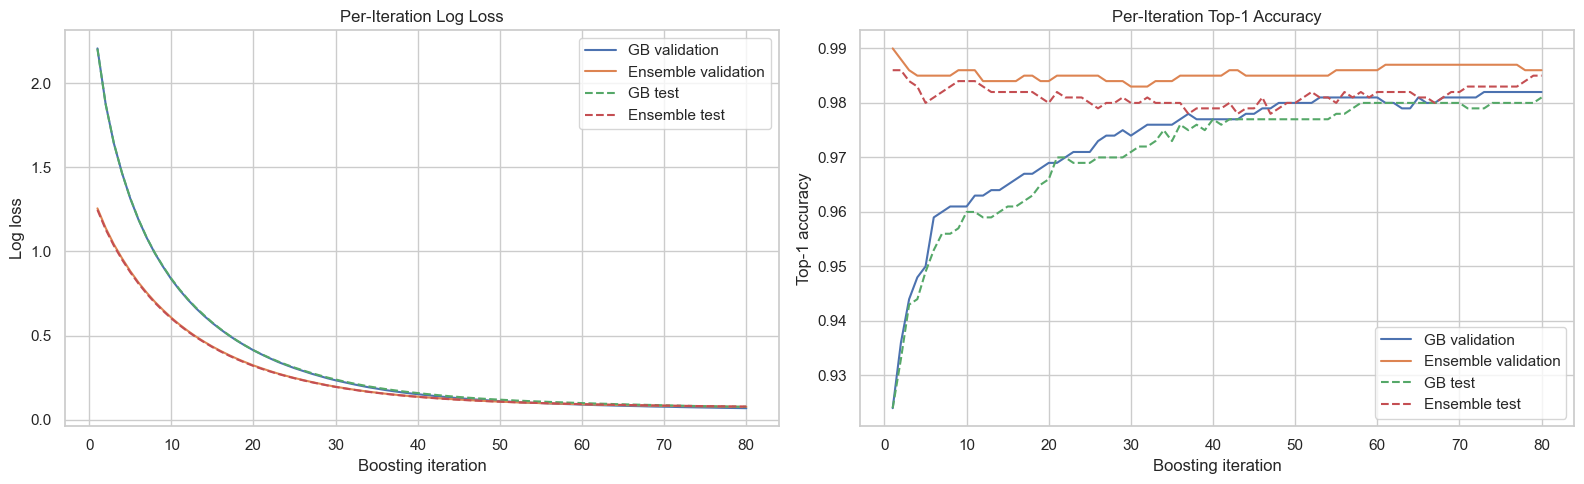

In [14]:
if gb_trace.empty:
    print("gradient_boosting_iteration_trace.csv is empty. Retrain the model with the updated pipeline, then rerun the export script.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(gb_trace["iteration"], gb_trace["gradient_boosting_validation_logLoss"], label="GB validation")
    axes[0].plot(gb_trace["iteration"], gb_trace["ensemble_validation_logLoss"], label="Ensemble validation")
    axes[0].plot(gb_trace["iteration"], gb_trace["gradient_boosting_test_logLoss"], label="GB test", linestyle="--")
    axes[0].plot(gb_trace["iteration"], gb_trace["ensemble_test_logLoss"], label="Ensemble test", linestyle="--")
    axes[0].set_title("Per-Iteration Log Loss")
    axes[0].set_xlabel("Boosting iteration")
    axes[0].set_ylabel("Log loss")
    axes[0].legend()

    axes[1].plot(gb_trace["iteration"], gb_trace["gradient_boosting_validation_top1"], label="GB validation")
    axes[1].plot(gb_trace["iteration"], gb_trace["ensemble_validation_top1"], label="Ensemble validation")
    axes[1].plot(gb_trace["iteration"], gb_trace["gradient_boosting_test_top1"], label="GB test", linestyle="--")
    axes[1].plot(gb_trace["iteration"], gb_trace["ensemble_test_top1"], label="Ensemble test", linestyle="--")
    axes[1].set_title("Per-Iteration Top-1 Accuracy")
    axes[1].set_xlabel("Boosting iteration")
    axes[1].set_ylabel("Top-1 accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

These retraining traces show how performance changes as gradient boosting adds more iterations, while also comparing the standalone boosting model with the final ensemble. In the log-loss panel, lower values over time indicate improved probability estimates; in the accuracy panel, higher values indicate better ranking of the correct career. If validation improves and then stabilizes without strong late-stage degradation, that suggests the model is learning useful structure rather than simply overfitting. This is an important training-process visualization because it lets you justify the training dynamics behind the final artifact.


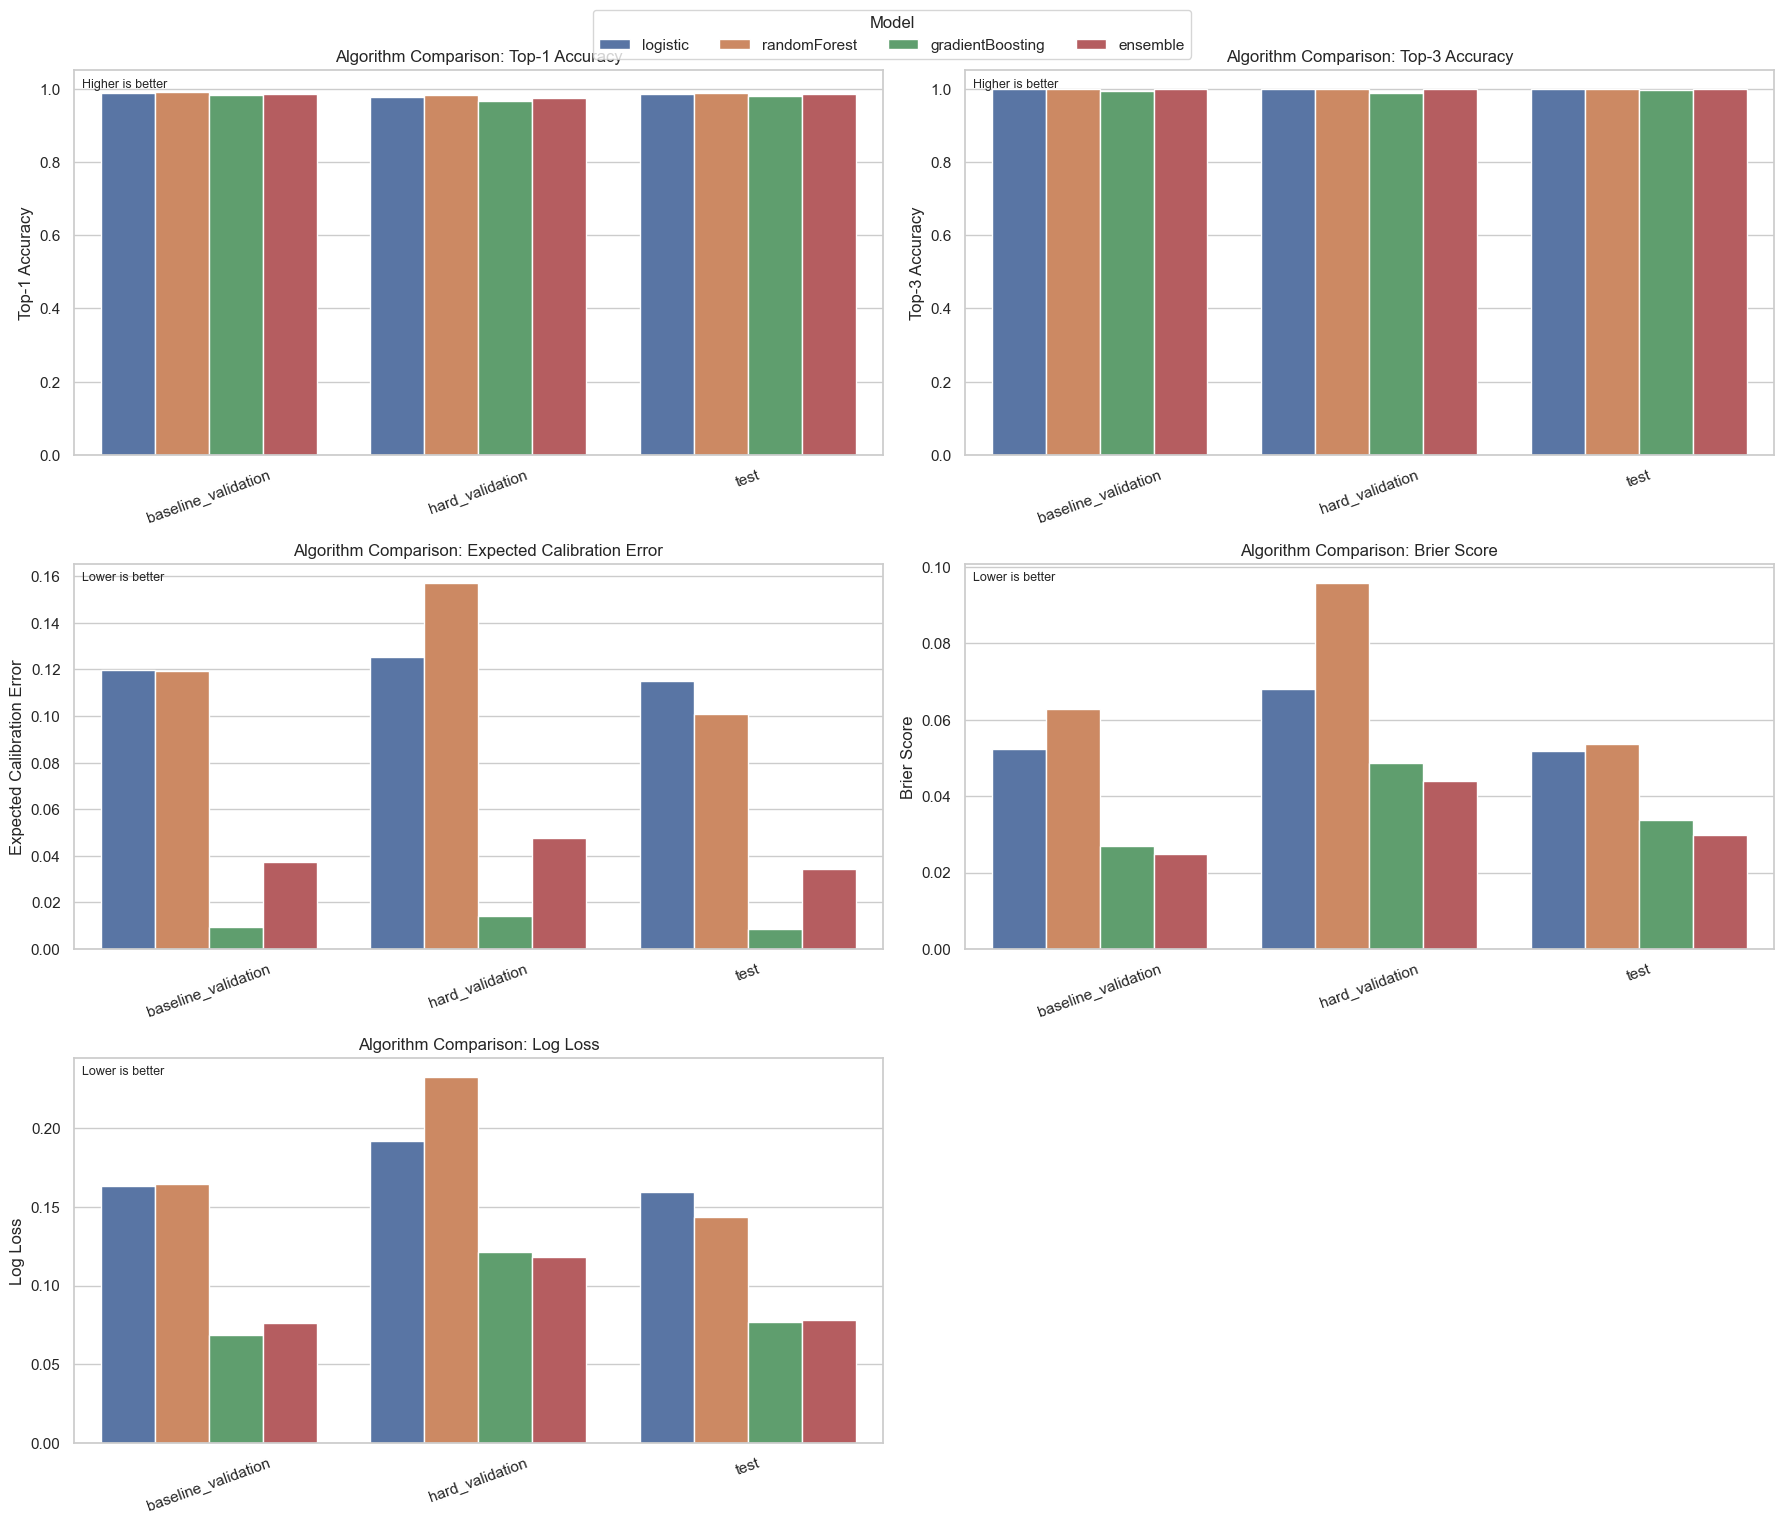

In [15]:
if evaluation_metrics.empty:
    print("evaluation_metrics.csv is empty or missing")
else:
    metric_specs = [
        ("top1", "Top-1 Accuracy", False),
        ("top3", "Top-3 Accuracy", False),
        ("ece", "Expected Calibration Error", True),
        ("brier", "Brier Score", True),
        ("logLoss", "Log Loss", True),
    ]
    split_order = ["baseline_validation", "hard_validation", "test"]
    model_order = ["logistic", "randomForest", "gradientBoosting", "ensemble"]
    metrics_frame = evaluation_metrics.copy()
    metrics_frame["split"] = pd.Categorical(metrics_frame["split"], categories=split_order, ordered=True)
    metrics_frame["model"] = pd.Categorical(metrics_frame["model"], categories=model_order, ordered=True)
    metrics_frame = metrics_frame.sort_values(["split", "model"])

    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    axes = axes.flatten()

    for ax, (metric, title, lower_is_better) in zip(axes, metric_specs):
        sns.barplot(data=metrics_frame, x="split", y=metric, hue="model", ax=ax)
        ax.set_title(f"Algorithm Comparison: {title}")
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=20)
        ax.set_ylabel(title)
        if lower_is_better:
            ax.text(0.01, 0.98, "Lower is better", transform=ax.transAxes, ha="left", va="top", fontsize=9)
        else:
            ax.text(0.01, 0.98, "Higher is better", transform=ax.transAxes, ha="left", va="top", fontsize=9)
        if metric in {"top1", "top3"}:
            ax.set_ylim(0.0, 1.05)
        ax.legend_.set_title("Model")

    axes[-1].axis("off")
    handles, labels = axes[0].get_legend_handles_labels()
    for ax in axes[:5]:
        if ax.legend_ is not None:
            ax.legend_.remove()
    fig.legend(handles, labels, title="Model", loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
    plt.tight_layout()
    plt.show()

These panels compare all algorithms used in the project across the key evaluation metrics: `top1`, `top3`, `ece`, `brier`, and `logLoss`. Logistic regression, random forest, gradient boosting, and the ensemble are shown side by side for each split so you can quickly explain not just which model wins overall, but how each model behaves under easier and harder validation conditions. For the thesis, this is useful because it supports model-selection decisions with a balanced view of accuracy, ranking quality, and calibration rather than relying on a single metric alone.


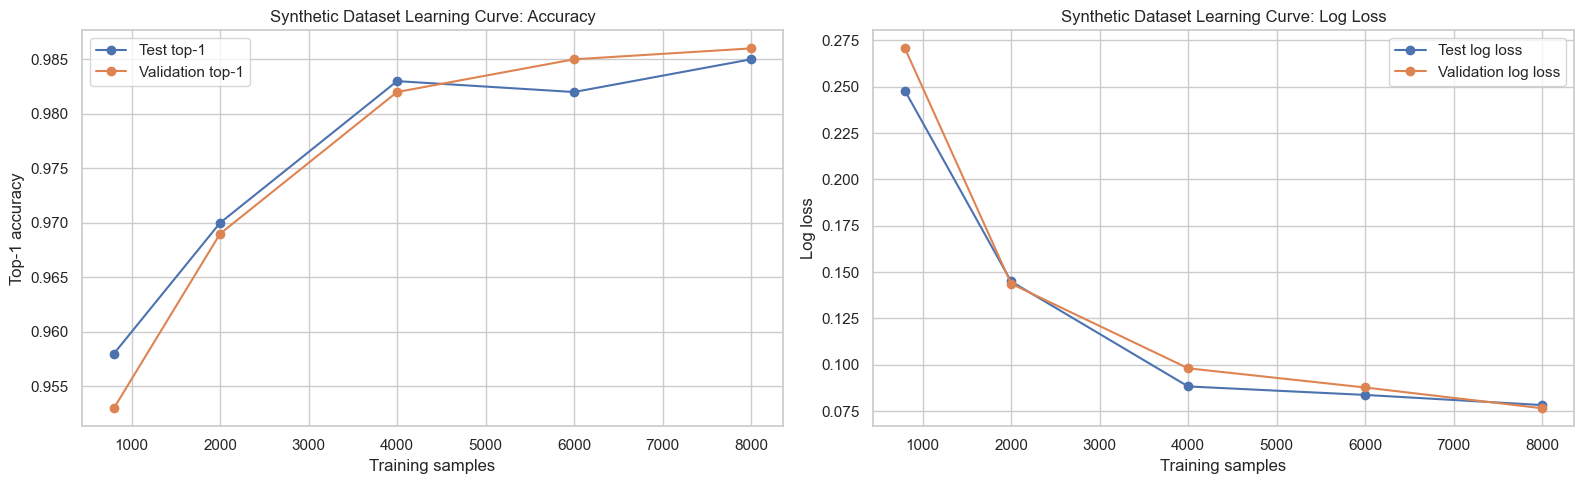

In [16]:
if learning_curve.empty:
    print("synthetic_learning_curve.csv is empty. Retrain the model with the updated pipeline, then rerun the export script.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(learning_curve["train_samples"], learning_curve["test_top1"], marker="o", label="Test top-1")
    axes[0].plot(learning_curve["train_samples"], learning_curve["validation_top1"], marker="o", label="Validation top-1")
    axes[0].set_title("Synthetic Dataset Learning Curve: Accuracy")
    axes[0].set_xlabel("Training samples")
    axes[0].set_ylabel("Top-1 accuracy")
    axes[0].legend()

    axes[1].plot(learning_curve["train_samples"], learning_curve["test_logLoss"], marker="o", label="Test log loss")
    axes[1].plot(learning_curve["train_samples"], learning_curve["validation_logLoss"], marker="o", label="Validation log loss")
    axes[1].set_title("Synthetic Dataset Learning Curve: Log Loss")
    axes[1].set_xlabel("Training samples")
    axes[1].set_ylabel("Log loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

This learning curve is one of the strongest pieces of evidence for the usefulness of the synthetic dataset. The left panel asks whether more synthetic training samples improve recommendation accuracy, and the right panel asks whether they reduce log loss. If accuracy rises and log loss falls as sample count increases, that supports the thesis claim that synthetic augmentation materially helps model training. If the curves begin to plateau, that is also valuable because it shows where additional synthetic data starts to provide diminishing returns.
